In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

In [2]:
df = pd.read_csv("data/final_dataset.csv")

df.head(5)

,utt_id,maya,spk_id,path
0,spk_001_utt_0001,baach,spk_001,audios/spk_001_utt_0001.wav
1,spk_001_utt_0002,chiich,spk_001,audios/spk_001_utt_0002.wav
2,spk_001_utt_0003,ch'íich',spk_001,audios/spk_001_utt_0003.wav
3,spk_001_utt_0004,ja',spk_001,audios/spk_001_utt_0004.wav
4,spk_001_utt_0005,kool,spk_001,audios/spk_001_utt_0005.wav


In [3]:
speakers = [f"spk_{x+1:03d}" for x in range(18)]
speakers

['spk_001',
 'spk_002',
 'spk_003',
 'spk_004',
 'spk_005',
 'spk_006',
 'spk_007',
 'spk_008',
 'spk_009',
 'spk_010',
 'spk_011',
 'spk_012',
 'spk_013',
 'spk_014',
 'spk_015',
 'spk_016',
 'spk_017',
 'spk_018']

In [4]:
df_cleaned = df[df["spk_id"].isin(speakers)][["spk_id","utt_id"]]
df_count = df_cleaned.groupby("spk_id").count().reset_index()
df_count

,spk_id,utt_id
0,spk_001,392
1,spk_002,155
2,spk_003,28
3,spk_004,28
4,spk_005,15
5,spk_006,334
6,spk_007,28
7,spk_008,29
8,spk_009,96
9,spk_010,59


In [5]:
df_spk = pd.read_csv("data/spk_metadata.csv")
df_spk.head(5)

,spk_id,description,sexo,nombre
0,spk_001,canal: filosofia maya,mujer,NaN
1,spk_002,canal: lengua cultura maya yucateca,hombre,NaN
2,spk_003,canal: lengua cultura maya yucateca,hombre,NaN
3,spk_004,canal: lengua cultura maya yucateca,mujer,NaN
4,spk_005,canal: lengua maya yucateco con maestro pat,hombre,NaN


In [6]:
import subprocess
from pathlib import Path
from datetime import timedelta
import re

def get_duration(file_path):
    cmd = [
        "ffprobe",
        "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        str(file_path)
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    try:
        return float(result.stdout.strip())
    except:
        return 0.0

def extract_number(path):
    match = re.search(r"/(\d+)_", str(path))
    if match:
        return int(match.group(1))
    return float("inf")

def total_audio_duration(directory, spk_id):
    directory = Path(directory)

    total_seconds = 0.0
    count = 0

    for file in directory.rglob(f"{spk_id}*"):
        if file.suffix.lower() in [".wav", ".mp3", ".flac", ".m4a"]:
            duration = get_duration(file)
            total_seconds += duration
            count += 1

    minutes = total_seconds / 60
    hours = total_seconds / 3600

    #print("\n===== RESUMEN =====")
    #print(f"Archivos procesados: {count}")
    #print(f"Total: {minutes:.2f} minutos")
    #print(f"Total: {hours:.2f} horas")

    return minutes

In [7]:
sample = df_count.iloc[0]
spk_id = sample["spk_id"]

values = []
for spk_id in df_count["spk_id"].values:
    print(spk_id)
    values.append(total_audio_duration("./audios", spk_id))

spk_001
spk_002
spk_003
spk_004
spk_005
spk_006
spk_007
spk_008
spk_009
spk_010
spk_011
spk_012
spk_013
spk_014
spk_015
spk_016
spk_017
spk_018


In [8]:
minutes = np.array(values)
minutes

array([15.62728333,  5.04933333,  0.69      ,  0.72035   ,  0.32416667,
       14.37131667,  0.66315   ,  1.875     ,  4.91251667,  2.86501667,
        1.839     ,  0.23166667,  0.60583333,  0.92733333,  0.7852    ,
        0.74056667,  0.43983862,  0.368223  ])

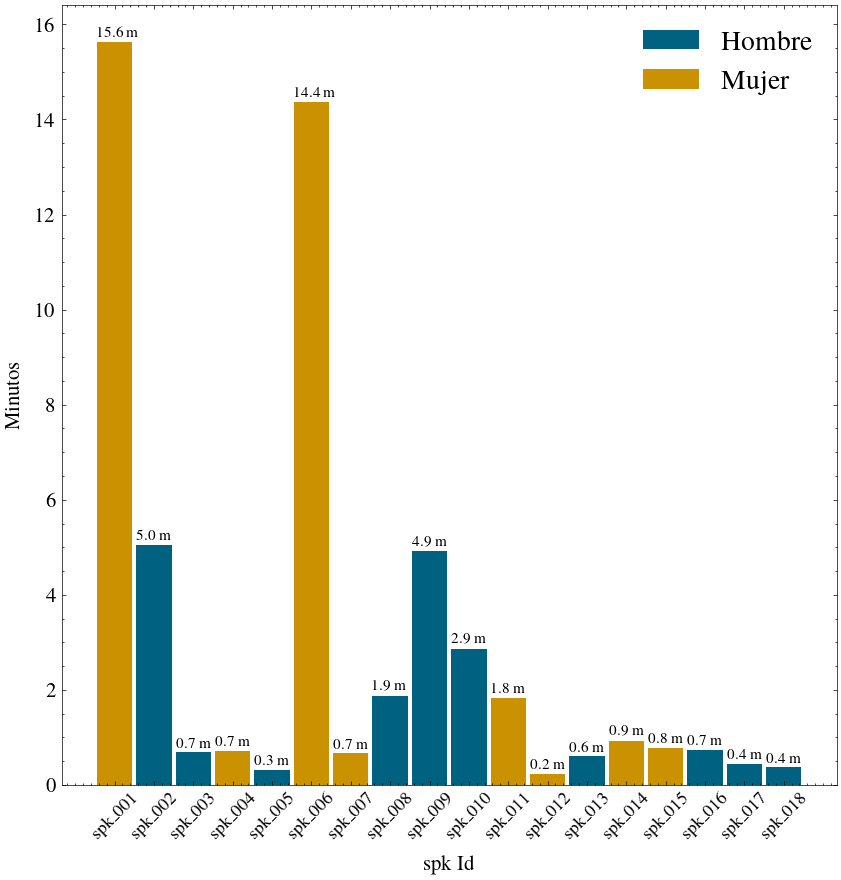

In [9]:
plt.figure(figsize=(10,10))
with plt.style.context(['science', 'ieee']):
    # Create bars
    barWidth = 0.9
    
    bars = minutes
    r = df_count["spk_id"].values
    
    # Crear mapeo de colores basado en sexo
    # Primero, crear un diccionario que relacione spk_id con sexo
    sex_map = dict(zip(df_spk['spk_id'], df_spk[' sexo']))
    
    # Definir colores para cada sexo
    colors = []
    for spk in r:
        if sex_map.get(spk) == 'hombre':
            colors.append("#006181")  # Azul turquesa (groupB)
        else:
            colors.append("#CA9100")  # Verde (groupC)
    
    # Create barplot
    plt.bar(r, bars, width = barWidth, color=colors)
    # Note: the barplot could be created easily. See the barplot section for other examples.
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#006181", label='Hombre'),
        Patch(facecolor="#CA9100", label='Mujer')
    ]
    plt.legend(handles=legend_elements, fontsize=20)
    
    # Text below each barplot with a rotation at 45°
    plt.xticks(rotation=45, size=13)
    plt.yticks(size=15)
    
    # Text on the top of each bar
    for i in range(len(r)):
        plt.text(x=i - 0.45, y=bars[i] + 0.1, s=f"{bars[i]:.1f} m", fontsize=11)
        #plt.text(x = r[i]-0.5 , y = bars[i]+0.1, s = label[i], size = 6)

    # Adjust the margins
    plt.subplots_adjust(bottom= 0.2, top = 0.98)
    
    # Show graphic
    plt.ylabel("Minutos", size=15, labelpad=9)
    plt.xlabel("spk Id", size=15, labelpad=10)
    plt.savefig("./figures/1h_count.svg", bbox_inches='tight', pad_inches=0)
    plt.show()